In [17]:
import pandas as pd
import numpy as np
from contextlib import contextmanager
from datetime import datetime
from pathlib import Path
from typing import Optional
import matplotlib.pyplot as plt
import polars as pl
import psutil
import seaborn as sns

# 1. Coinmetrics

In [22]:
# read data
df = pd.read_csv("../data/Coin Metrics/coinmetrics_btc.csv")
df["time"] = pd.to_datetime(df["time"])
df.head()

,time,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,...,ReferenceRateETH,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d
0,2009-01-03,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,0.000000e+00,0.000000e+00,NaN,NaN,0.0,0.0,NaN
1,2009-01-04,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,0.000000e+00,0.000000e+00,NaN,NaN,0.0,0.0,NaN
2,2009-01-05,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,0.000000e+00,0.000000e+00,NaN,NaN,0.0,0.0,NaN
3,2009-01-06,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,0.000000e+00,0.000000e+00,NaN,NaN,0.0,0.0,NaN
4,2009-01-07,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,0.000000e+00,0.000000e+00,NaN,NaN,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6216,2026-01-10,608784.0,55908713.0,1.768101e+09,1.768101e+09,162.0,1.610013,1.805781e+12,1.805753e+12,2.085347,...,29.348301,77853.756824,90539.603229,1.997410e+07,2.480800e+06,2.242796e+11,2.082608e+07,492984.0,1049925.0,2.998463e+09
6217,2026-01-11,536405.0,55924280.0,1.768187e+09,1.768187e+09,122.0,1.615856,1.812029e+12,1.812010e+12,1.915416,...,29.333069,77790.505193,90406.142411,1.997448e+07,2.484575e+06,2.253937e+11,2.082618e+07,289219.0,572262.0,4.399753e+09
6218,2026-01-12,638422.0,55917951.0,1.768275e+09,1.768275e+09,142.0,1.623512,1.820538e+12,1.820513e+12,2.322577,...,29.145653,78047.851052,90717.206315,1.997493e+07,2.482087e+06,2.262203e+11,2.082629e+07,405384.0,845895.0,1.344799e+10
6219,2026-01-13,701272.0,55891967.0,1.768360e+09,1.768360e+09,135.0,1.695646,1.903741e+12,1.903718e+12,3.019455,...,29.485280,78130.277588,91141.149849,1.997535e+07,2.474529e+06,2.358337e+11,2.082639e+07,340763.0,731900.0,1.805277e+10


In [23]:
# test the commit
start = "2018-01-01"
end = "2025-12-31"
df = df[(df["time"] >= start) & (df["time"] <= end)].copy()
# sort and set the index
df = df.sort_values("time").set_index("time")

In [ ]:
# check missing date
all_days = pd.date_range(start, end, freq="D")
missing_days = all_days.difference(df.index)
len(missing_days)

0

In [ ]:
# missing rate
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("missing rate Top 20（%）：")
print(missing_pct.head(20))

key_cols = [
    "PriceUSD", "CapMrktCurUSD", "HashRate", "TxCnt",
    "CapMVRVCur", "SplyCur", "FeeTotNtv",
    "FlowInExUSD", "FlowOutExUSD",
    "volume_reported_spot_usd_1d"
]
key_cols = [c for c in key_cols if c in df.columns]

print("\nkey row describe：")
print(df[key_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

缺失率 Top 20（%）：
ReferenceRate                  100.000000
ReferenceRateETH               100.000000
ReferenceRateEUR               100.000000
ReferenceRateUSD               100.000000
CapMrktEstUSD                   18.377823
price_vs_ma200                   6.810404
ma_200                           6.810404
vol_30d                          1.026694
logret_1d                        0.034223
ret_1d                           0.034223
SplyExNtv                        0.000000
SplyCur                          0.000000
AdrActCnt                        0.000000
SplyExUSD                        0.000000
SplyExpFut10yr                   0.000000
TxCnt                            0.000000
ROI30d                           0.000000
volume_reported_spot_usd_1d      0.000000
TxTfrCnt                         0.000000
ROI1yr                           0.000000
dtype: float64

关键列 describe：
                              count          mean           std           min  \
PriceUSD                     2922.

In [ ]:
# 6) create metrics

px = df["PriceUSD"]

df["ret_1d"] = px.pct_change()
df["logret_1d"] = np.log(px).diff()

# annualized vol
df["vol_30d"] = df["logret_1d"].rolling(30).std() * np.sqrt(365)

# 200 DMA
df["ma_200"] = px.rolling(200).mean()
df["price_vs_ma200"] = px / df["ma_200"] - 1

# Drawdown
rolling_max = px.cummax()
df["drawdown"] = px / rolling_max - 1


In [37]:
df.columns

Index(['AdrActCnt', 'AdrBalCnt', 'AssetCompletionTime',
       'AssetEODCompletionTime', 'BlkCnt', 'CapMVRVCur', 'CapMrktCurUSD',
       'CapMrktEstUSD', 'FeeTotNtv', 'FlowInExNtv', 'FlowInExUSD',
       'FlowOutExNtv', 'FlowOutExUSD', 'HashRate', 'IssTotNtv', 'IssTotUSD',
       'PriceBTC', 'PriceUSD', 'ROI1yr', 'ROI30d', 'ReferenceRate',
       'ReferenceRateETH', 'ReferenceRateEUR', 'ReferenceRateUSD', 'SplyCur',
       'SplyExNtv', 'SplyExUSD', 'SplyExpFut10yr', 'TxCnt', 'TxTfrCnt',
       'volume_reported_spot_usd_1d', 'ret_1d', 'logret_1d', 'vol_30d',
       'ma_200', 'price_vs_ma200', 'drawdown'],
      dtype='object')

In [64]:
df.head()

,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,...,ret_1d,logret_1d,vol_30d,ma_200,price_vs_ma200,drawdown,net_flow_usd,fwd_ret_30d,fwd_vol_30d,fwd_min_dd_30d
time,,,,,,,,,,,,,,,,,,,,,
2018-01-01,972783.0,26829117.0,1.614337e+09,1.614337e+09,156.0,2.694235,2.258877e+11,NaN,477.225170,36000.622080,...,NaN,NaN,NaN,NaN,NaN,0.0,1.291811e+08,-0.253594,NaN,NaN
2018-01-02,1142721.0,26909375.0,1.614337e+09,1.614337e+09,171.0,2.925443,2.475552e+11,NaN,649.878138,65831.310897,...,0.095782,0.091468,NaN,NaN,NaN,0.0,-2.480938e+08,-0.387307,NaN,NaN
2018-01-03,1130917.0,27133378.0,1.614337e+09,1.614337e+09,157.0,2.960267,2.518793e+11,NaN,750.020447,56969.474964,...,0.017348,0.017200,NaN,NaN,NaN,0.0,-1.441119e+08,-0.414663,NaN,NaN
2018-01-04,1253986.0,27415056.0,1.614337e+09,1.614337e+09,168.0,2.944022,2.529181e+11,NaN,777.017867,77816.063305,...,0.003998,0.003990,NaN,NaN,NaN,0.0,-8.682248e+07,-0.394033,NaN,NaN
2018-01-05,1069525.0,27645350.0,1.614337e+09,1.614337e+09,143.0,3.261964,2.852872e+11,NaN,704.313737,72765.218396,...,0.127863,0.120324,NaN,NaN,NaN,0.0,-3.374689e+07,-0.514596,NaN,NaN


# 2. Coinmetrics EDA

In [33]:
metrics = ["PriceUSD", "CapMrktCurUSD", "HashRate"]
df[metrics].describe()

,PriceUSD,CapMrktCurUSD,HashRate
count,2922.000000,2.922000e+03,2.922000e+03
mean,37263.830507,7.219058e+11,3.164267e+08
std,32224.168884,6.439132e+11,3.023951e+08
min,3185.074044,5.549965e+10,1.372762e+07
25%,9447.177429,1.706965e+11,9.550205e+07
50%,27320.277455,5.303925e+11,1.780076e+08
75%,57402.905528,1.085182e+12,5.065075e+08
max,124824.453667,2.487865e+12,1.305500e+09


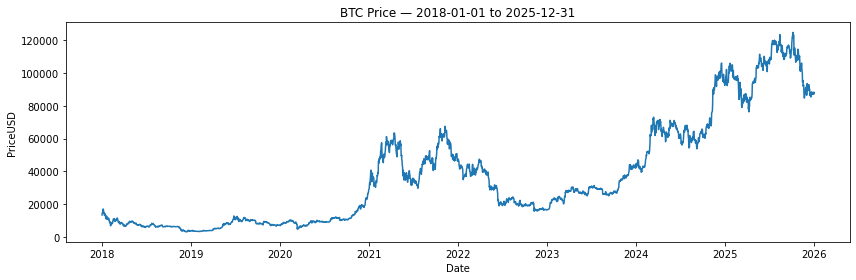

In [ ]:
# Price Trend
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["PriceUSD"])
plt.title("BTC Price — 2018-01-01 to 2025-12-31")
plt.xlabel("Date")
plt.ylabel("PriceUSD")
plt.tight_layout()
plt.show()

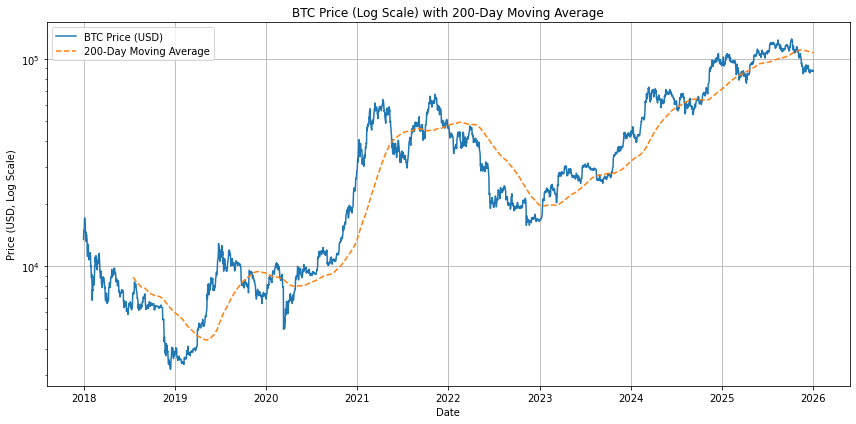

In [44]:
# BTC Price (Log Scale) with 200-Day Moving Average
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["PriceUSD"], label="BTC Price (USD)")
plt.plot(df.index, df["ma_200"], label="200-Day Moving Average", linestyle="--")

plt.yscale("log")

plt.title("BTC Price (Log Scale) with 200-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price (USD, Log Scale)")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

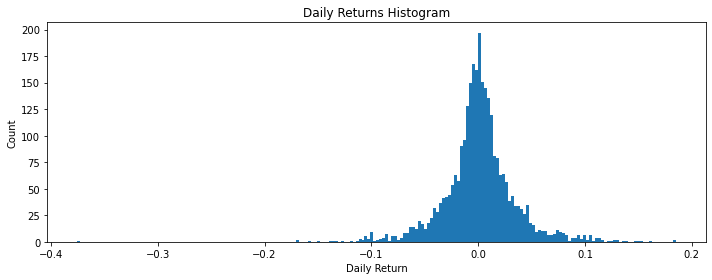

In [ ]:
# Daily Profit Distribution
rets = df["ret_1d"].dropna()
plt.figure(figsize=(10, 4))
plt.hist(rets, bins=200)
plt.title("Daily Returns Histogram")
plt.xlabel("Daily Return")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [48]:
print("\nWorst 10 Days (ret_1d):")
print(rets.nsmallest(10))

print("\nBest 10 Days (ret_1d):")
print(rets.nlargest(10))


Worst 10 Days (ret_1d):
time
2020-03-12   -0.375350
2018-02-05   -0.169805
2022-06-13   -0.168244
2018-01-16   -0.158969
2022-11-09   -0.149165
2018-11-19   -0.137376
2019-06-27   -0.136329
2019-07-16   -0.133186
2021-01-21   -0.126495
2021-05-19   -0.120292
Name: ret_1d, dtype: float64

Best 10 Days (ret_1d):
time
2019-04-02    0.184926
2021-02-08    0.182522
2019-10-25    0.161286
2019-05-11    0.152202
2020-03-19    0.150406
2022-02-28    0.146409
2018-04-12    0.138168
2020-03-13    0.134772
2018-02-06    0.129804
2019-05-19    0.129398
Name: ret_1d, dtype: float64


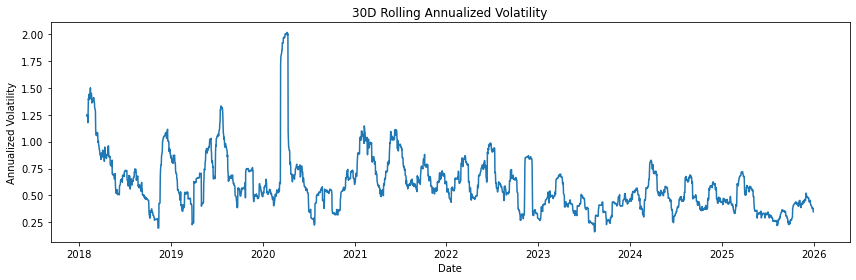

In [ ]:
# 30D Rolling Annualized Volatility
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["vol_30d"])
plt.title("30D Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.tight_layout()
plt.show()

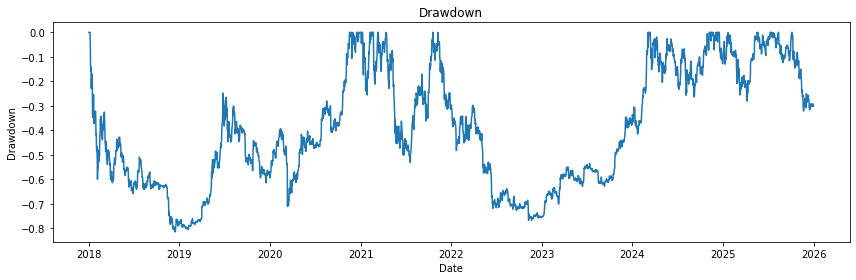

In [ ]:
# Drawdown Plot
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["drawdown"])
plt.title("Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.tight_layout()
plt.show()

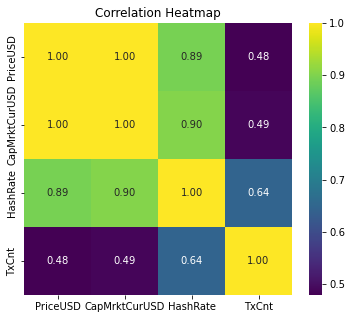

In [ ]:
#Correlation Heatmap
correlation_cols = ["PriceUSD", "CapMrktCurUSD", "HashRate", "TxCnt"]
corr_df = df[correlation_cols].apply(pd.to_numeric, errors="coerce")

# corr
corr = corr_df.corr()

# heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

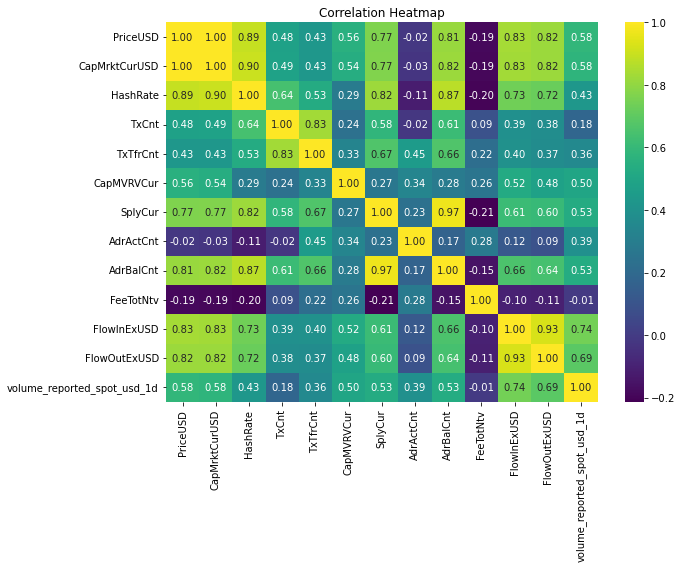

In [42]:
corr_cols = [
    "PriceUSD", "CapMrktCurUSD", "HashRate", "TxCnt", "TxTfrCnt",
    "CapMVRVCur", "SplyCur", "AdrActCnt", "AdrBalCnt",
    "FeeTotNtv", "FlowInExUSD", "FlowOutExUSD",
    "volume_reported_spot_usd_1d"
]
corr_cols = [c for c in corr_cols if c in df.columns]

corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
# Build accumulation common metrics
# net inflow >0 means net outflow ，<0 means net inflow
df["net_flow_usd"] = df["FlowOutExUSD"] - df["FlowInExUSD"]

# PnL in next 30 days
h = 30
df["fwd_ret_30d"] = df["PriceUSD"].shift(-h) / df["PriceUSD"] - 1

# Forward vol in 30D log return
logret = np.log(df["PriceUSD"]).diff()
df["fwd_vol_30d"] = logret.shift(-1).rolling(h).std() * np.sqrt(365)

# Max Drawdown in next 30D
# Make the lowest price in the forward window, then convert to max drawdown
future_min_price = df["PriceUSD"].shift(-1).rolling(h).min()
df["fwd_min_dd_30d"] = future_min_price / df["PriceUSD"] - 1 

# Remove missing data in the last 30D
eda = df.dropna(subset=["fwd_ret_30d", "fwd_vol_30d", "fwd_min_dd_30d"]).copy()



=== 按 MVRV（CapMVRVCur）五分位分箱结果 ===
  mvrv_q5    n  avg_fwd_ret_30d  med_fwd_ret_30d  avg_fwd_vol_30d  \
0       1  573         0.075359         0.054146         0.670342   
1       2  572         0.020615         0.000193         0.527412   
2       3  573         0.030614         0.012754         0.654079   
3       4  572         0.045156         0.012082         0.562571   
4       5  573         0.043455        -0.008083         0.601273   

   prob_dd_lt_20pct  prob_dd_lt_30pct  
0          0.136126          0.001745  
1          0.092657          0.008741  
2          0.211169          0.050611  
3          0.164336          0.050699  
4          0.392670          0.184991  


/Users/shuangshuang/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 20116 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/shuangshuang/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 20998 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/shuangshuang/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 20301 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/shuangshuang/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 65288 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/shuangshuang/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 20302 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/shuangshuang/opt/anacon

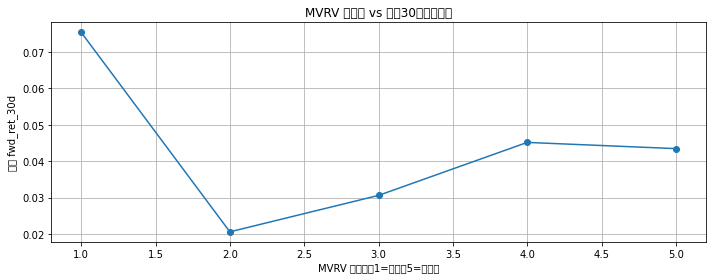

In [ ]:
#One dimensional bin analysis 

#Group into 5 buckets by MVRV
eda["mvrv_q5"] = pd.qcut(eda["CapMVRVCur"], 5, labels=[1,2,3,4,5])
mvrv_table = eda.groupby("mvrv_q5").agg(
    n=("PriceUSD", "size"),
    avg_fwd_ret_30d=("fwd_ret_30d", "mean"),
    med_fwd_ret_30d=("fwd_ret_30d", "median"),
    avg_fwd_vol_30d=("fwd_vol_30d", "mean"),
    prob_dd_lt_20pct=("fwd_min_dd_30d", lambda x: (x < -0.20).mean()),
    prob_dd_lt_30pct=("fwd_min_dd_30d", lambda x: (x < -0.30).mean()),
).reset_index()

print("\n===  MVRV（CapMVRVCur）5 Buckets Grouping Result ===")
print(mvrv_table)

plt.figure(figsize=(10,4))
plt.plot(mvrv_table["mvrv_q5"], mvrv_table["avg_fwd_ret_30d"], marker="o")
plt.title("MVRV Quintiles vs Future 30-Day Average Returns")
plt.xlabel("MVRV Quintile (1=Undervalued, 5=Overvalued)")
plt.ylabel("Average fwd_ret_30d")
plt.grid(True)
plt.tight_layout()
plt.show()


=== 按 净流（net_flow_usd）五分位分箱结果 ===
  netflow_q5    n  avg_fwd_ret_30d  med_fwd_ret_30d  avg_fwd_vol_30d  \
0          1  573         0.019433        -0.014197         0.624681   
1          2  572         0.044643         0.022561         0.616223   
2          3  573         0.052355         0.025048         0.620103   
3          4  572         0.061835         0.027716         0.610376   
4          5  573         0.037003         0.007718         0.544532   

   prob_dd_lt_20pct  prob_dd_lt_30pct  
0          0.226876          0.099476  
1          0.187063          0.052448  
2          0.202443          0.043630  
3          0.201049          0.043706  
4          0.179756          0.057592  


/Users/shuangshuang/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 20928 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/shuangshuang/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 27969 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/shuangshuang/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 20116 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/shuangshuang/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 20998 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/shuangshuang/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 20301 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/shuangshuang/opt/anacon

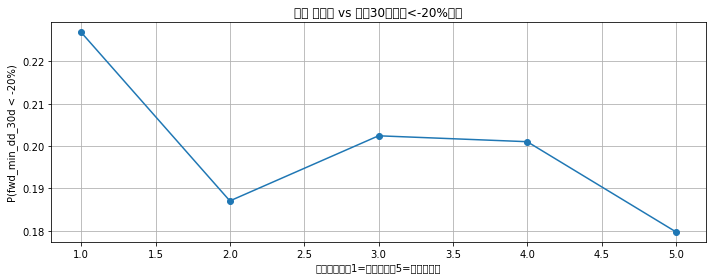

In [ ]:
# Based on net_flow_usd group into 5
eda["netflow_q5"] = pd.qcut(eda["net_flow_usd"], 5, labels=[1,2,3,4,5])
netflow_table = eda.groupby("netflow_q5").agg(
    n=("PriceUSD", "size"),
    avg_fwd_ret_30d=("fwd_ret_30d", "mean"),
    med_fwd_ret_30d=("fwd_ret_30d", "median"),
    avg_fwd_vol_30d=("fwd_vol_30d", "mean"),
    prob_dd_lt_20pct=("fwd_min_dd_30d", lambda x: (x < -0.20).mean()),
    prob_dd_lt_30pct=("fwd_min_dd_30d", lambda x: (x < -0.30).mean()),
).reset_index()

print("\n=== Net Flow (net_flow_usd) Quintile Binning Results ===")
print(netflow_table)

plt.figure(figsize=(10,4))
plt.plot(netflow_table["netflow_q5"], netflow_table["prob_dd_lt_20pct"], marker="o")
plt.title("Net Flow Quintiles vs Future 30-Day Drawdown <-20% Probability")
plt.xlabel("Net Flow Quintile (1=Strong Inflow, 5=Strong Outflow)")
plt.ylabel("P(fwd_min_dd_30d < -20%)")
plt.grid(True)
plt.tight_layout()
plt.show()


=== 按 活跃地址（AdrActCnt）五分位分箱结果 ===
  adract_q5    n  avg_fwd_ret_30d  med_fwd_ret_30d  avg_fwd_vol_30d  \
0         1  573         0.017177        -0.002325         0.630627   
1         2  572         0.021092         0.001985         0.569494   
2         3  573         0.059636         0.023675         0.613425   
3         4  572         0.042854         0.012553         0.584313   
4         5  573         0.074436         0.038444         0.617930   

   prob_dd_lt_20pct  prob_dd_lt_30pct  
0          0.101222          0.008726  
1          0.125874          0.045455  
2          0.211169          0.057592  
3          0.230769          0.055944  
4          0.328098          0.129145  


/Users/shuangshuang/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 27963 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/shuangshuang/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 36291 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/shuangshuang/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 22320 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/shuangshuang/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 22336 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/shuangshuang/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 20116 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/shuangshuang/opt/anacon

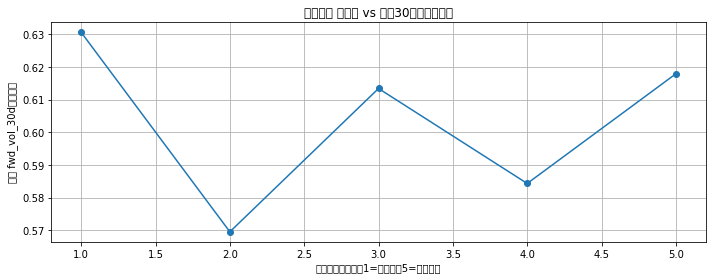

In [ ]:
#  AdrActCnt 5 binning
eda["adract_q5"] = pd.qcut(eda["AdrActCnt"], 5, labels=[1,2,3,4,5])
adr_table = eda.groupby("adract_q5").agg(
    n=("PriceUSD", "size"),
    avg_fwd_ret_30d=("fwd_ret_30d", "mean"),
    med_fwd_ret_30d=("fwd_ret_30d", "median"),
    avg_fwd_vol_30d=("fwd_vol_30d", "mean"),
    prob_dd_lt_20pct=("fwd_min_dd_30d", lambda x: (x < -0.20).mean()),
    prob_dd_lt_30pct=("fwd_min_dd_30d", lambda x: (x < -0.30).mean()),
).reset_index()

print("\n=== （AdrActCnt）Quintile Binning Results ===")
print(adr_table)

plt.figure(figsize=(10,4))
plt.plot(adr_table["adract_q5"], adr_table["avg_fwd_vol_30d"], marker="o")
plt.title("AdrActCnt Quintiles vs Future 30-Day Average Volatility")
plt.xlabel("AdrActCnt Quintile (1=Low Activity, 5=High Activity)）")
plt.ylabel("Average fwd_vol_30d（Annualized）")
plt.grid(True)
plt.tight_layout()
plt.show()

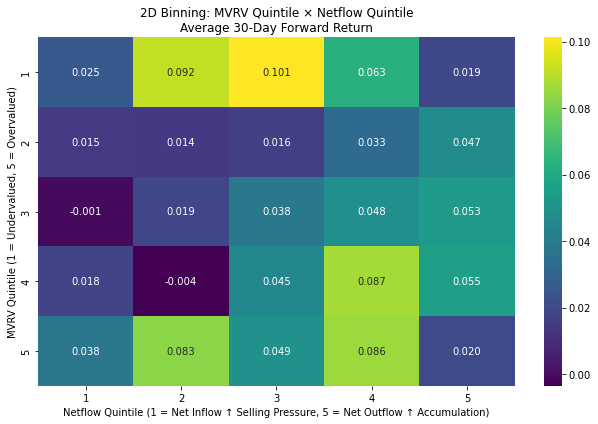

In [58]:
# 2D Binning: MVRV × Netflow
pivot = eda.pivot_table(
    index="mvrv_q5",
    columns="netflow_q5",
    values="fwd_ret_30d",
    aggfunc="mean"
)

plt.figure(figsize=(9,6))
sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".3f")

plt.title("2D Binning: MVRV Quintile × Netflow Quintile\nAverage 30-Day Forward Return")
plt.xlabel("Netflow Quintile (1 = Net Inflow ↑ Selling Pressure, 5 = Net Outflow ↑ Accumulation)")
plt.ylabel("MVRV Quintile (1 = Undervalued, 5 = Overvalued)")

plt.tight_layout()
plt.show()

# 3. Polymarket data loading

In [61]:
#read polymarket data
import sys
import os
import polars as pl
#from pathlib import path

sys.path.append(os.path.abspath('..'))
# Import the loader from the template provided by the project
from eda_starter_template import load_polymarket_data, POLYMARKET_DIR

# Load the dictionary of DataFrames
poly_data_dict = load_polymarket_data(POLYMARKET_DIR)

# Extract individual DataFrames for easier use
if poly_data_dict:
    df_markets = poly_data_dict.get("markets")
    df_odds = poly_data_dict.get("odds")
    df_summary = poly_data_dict.get("summary")
    
    print("Data loaded successfully!")
else:
    print("Data directory not found. Check if the 'data/Polymarket' folder exists.")

Loading Polymarket data from /Users/shuangshuang/Documents/GitHub/bitcoin-analytics-capstone-sp26-team08/data/Polymarket...
[Memory] Before loading Polymarket data: 328.20 MB
Loaded 78321 markets.
Loaded 2143181 odds history records.
Loaded 78321 summary records.
[Memory] After loading Polymarket data: 418.43 MB (Δ 90.23 MB)


# 3.1 Markets

In [20]:
df_markets.head()

market_id,question,slug,event_slug,category,volume,active,closed,created_at,end_date
str,str,str,str,str,f64,bool,bool,datetime[μs],datetime[μs]
"""242851""","""Will Bongbong Marcos be electe…","""will-bongbong-marcos-be-electe…","""will-bongbong-marcos-be-electe…","""Global Politics""",21533.53,true,true,2022-04-05 20:37:30,2022-05-09 00:00:00
"""242873""","""Will Sarah Palin win Alaska's …","""will-sarah-palin-win-in-the-al…","""will-sarah-palin-win-in-the-al…","""US-current-affairs""",79783.23,true,true,2022-04-05 22:41:57,2022-08-16 00:00:00
"""242918""","""Will US student loan payments …","""will-us-student-loan-payments-…","""will-us-student-loan-payments-…","""US-current-affairs""",18946.72,true,true,2022-04-05 23:33:47,2022-11-08 00:00:00
"""243183""","""Will $ETH be above $3,000 on A…","""will-eth-be-above-3000-on-apri…","""will-eth-be-above-3000-on-apri…","""Crypto""",974114.26,true,true,2022-04-12 16:51:10,2022-04-20 00:00:00
"""243192""","""Will Brian Kemp win the Republ…","""will-brian-kemp-win-the-republ…","""who-will-win-the-republican-no…","""US-current-affairs""",7024.92,true,true,2022-04-13 01:40:25,2022-05-24 00:00:00


# 3.4 Odds History

In [63]:
df_odds.head()

market_id,token_id,timestamp,price
str,str,datetime[μs],f64
"""255140""","""474357953615233060686693901910…",2024-06-08 00:00:02,0.055
"""255140""","""474357953615233060686693901910…",2024-06-09 00:00:03,0.055
"""255140""","""474357953615233060686693901910…",2024-06-10 00:00:04,0.055
"""255140""","""474357953615233060686693901910…",2024-06-11 00:00:02,0.055
"""255140""","""474357953615233060686693901910…",2024-06-12 00:00:03,0.055
